In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from PIL import Image

In [18]:
from PIL import Image
import os

dataset_path = "PetImages"

bad_images = []

for folder in ["Cat", "Dog"]:

    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):

        path = os.path.join(folder_path, file)

        try:
            img = Image.open(path)
            img.verify()      # Verify image integrity

        except Exception:
            bad_images.append(path)

print("Corrupted Images :", len(bad_images))

for img in bad_images:
    os.remove(img)

print("Removed all corrupted images.")

/home/labmsc04/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Images : 4
Removed all corrupted images.


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [20]:
dataset_path = "PetImages"       # Change if necessary

In [21]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

In [22]:
dataset = datasets.ImageFolder(
            root=dataset_path,
            transform=transform)

print("Classes :", dataset.classes)
print("Number of Images :", len(dataset))

Classes : ['Cat', 'Dog']
Number of Images : 24998


In [23]:
train_size = int(0.7 * len(dataset))
remaining_size = len(dataset) - train_size

train_dataset, remaining_dataset = random_split(
    dataset,
    [train_size, remaining_size]
)

validation_size = int(0.5 * remaining_size)
test_size = remaining_size - validation_size

validation_dataset, test_dataset = random_split(
    remaining_dataset,
    [validation_size, test_size]
)

print("Training :", len(train_dataset))
print("Validation :", len(validation_dataset))
print("Testing :", len(test_dataset))

Training : 17498
Validation : 3750
Testing : 3750


In [24]:
batch_size = 32

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Validation DataLoader
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Testing DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train batches: 547
Validation batches: 118
Test batches: 118


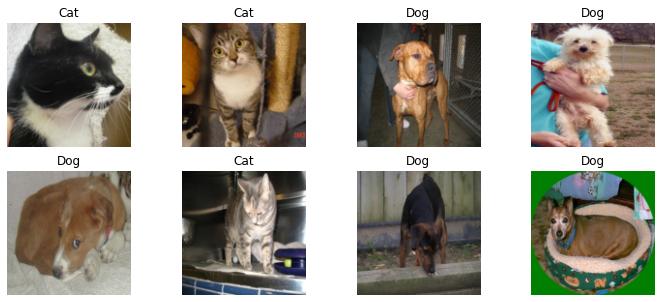

In [25]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i]/2 + 0.5

    plt.imshow(np.transpose(img.numpy(),(1,2,0)))

    plt.title(dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

In [26]:
import torch.nn as nn

class CatDogCNN(nn.Module):

    def __init__(self):
        super(CatDogCNN, self).__init__()

        # Feature Extraction
        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(in_channels=3,
                      out_channels=32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 2
            nn.Conv2d(32,
                      64,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Layer 3
            nn.Conv2d(64,
                      128,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        # Classifier
        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 2)

        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x

In [27]:
model = CatDogCNN().to(device)

print(model)

CatDogCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [29]:
nn.Linear(32768, 512)

Linear(in_features=32768, out_features=512, bias=True)

In [30]:
num_epochs = 20

train_loss_history = []
train_acc_history = []

val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):

    ##############################
    # Training
    ##############################

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_accuracy)

    ##############################
    # Validation
    ##############################

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(validation_loader)
    val_accuracy = 100 * correct / total

    val_loss_history.append(val_loss)
    val_acc_history.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss : {train_loss:.4f} | Train Accuracy : {train_accuracy:.2f}%")
    print(f"Validation Loss : {val_loss:.4f} | Validation Accuracy : {val_accuracy:.2f}%")
    print("-"*60)

Epoch [1/20]
Train Loss : 0.6128 | Train Accuracy : 65.33%
Validation Loss : 0.5285 | Validation Accuracy : 73.63%
------------------------------------------------------------
Epoch [2/20]
Train Loss : 0.4912 | Train Accuracy : 76.35%
Validation Loss : 0.4348 | Validation Accuracy : 80.19%
------------------------------------------------------------
Epoch [3/20]
Train Loss : 0.4063 | Train Accuracy : 81.80%
Validation Loss : 0.4162 | Validation Accuracy : 80.99%
------------------------------------------------------------
Epoch [4/20]
Train Loss : 0.3378 | Train Accuracy : 85.31%
Validation Loss : 0.4067 | Validation Accuracy : 81.28%
------------------------------------------------------------
Epoch [5/20]
Train Loss : 0.2578 | Train Accuracy : 89.17%
Validation Loss : 0.3737 | Validation Accuracy : 83.23%
------------------------------------------------------------
Epoch [6/20]
Train Loss : 0.1826 | Train Accuracy : 92.72%
Validation Loss : 0.3799 | Validation Accuracy : 83.89%
-----

In [ ]:
torch.save(model.state_dict(), "CatDogCNN.pth") 
print("Model saved successfully.")

In [ ]:
model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total

print(f"Test Accuracy = {accuracy:.2f}%")

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes
))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_history, label="Training Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Training Loss")
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import random

model.eval()

plt.figure(figsize=(15,8))

for i in range(8):

    index = random.randint(0, len(test_dataset)-1)

    image, label = test_dataset[index]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(input_image)

        prediction = torch.argmax(output,1).item()

    img = image/2 + 0.5

    plt.subplot(2,4,i+1)

    plt.imshow(img.permute(1,2,0))

    plt.title(f"True : {dataset.classes[label]}\nPred : {dataset.classes[prediction]}")

    plt.axis("off")

plt.tight_layout()

plt.show()